# Combined Model Chromatin Deconvolution

May 29, 2025

Deep dive into two loci: An early and late replicating region.

## Goals:
1. Convey the need for copy correction clearly.
2. Show how deconvolution improves the signal of cycling chromatin dynamics.

## Loci:
1. ARS220 (oridb 68) - Near *MCM7*
2. ARS1625.5 (oridb 817) - Early replicating and near *CLB2* and *CLB5*

## Notes and ideas
- Use one of these early replicating regions as a baseline and compare a nearby late replicating region, convey the distance to the efficient early replicating region on a chromosome summary plot above to provide context for the reader.
    - Tension: Using origin annotations rather than replication profiles (next section).
    - Figure/diagram ideas may help the replication, copy correction story.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
from src.origins import load_origins

origins = load_origins()
origin = origins.loc['oridb_817']
origin

chr                                                                                  16
pos                                                                              777099
strand                                                                                -
footprint_class                                                     g1_and_g2_footprint
nucleosome_shift_class                                                         upstream
mcm_loading_class                                                            downstream
activation_time                                                                   early
derived_origin_efficiency_from_mcguffee_et_al_2013                               0.7857
acs_sequence                                          TTTATTTATATTTTGGCATTACTCTTCATCATT
log2_acs_motif_score                                                            18.2426
ars_name                                                                      ARS1626.5
ars_start                       

In [9]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis
outdir = 'output/draft3_run/chromatin_deconvolution_partial_daughter/deconvolution_data/'
genome_analysis = GenomeDeconvolutionAnalysis(outdir)

In [171]:
span = origin.pos-6500, origin.pos+3500
_ = genome_analysis.load_mnase_span(origin.chr, span)

Saved figure to: /Users/trung/Desktop/example_locus.png


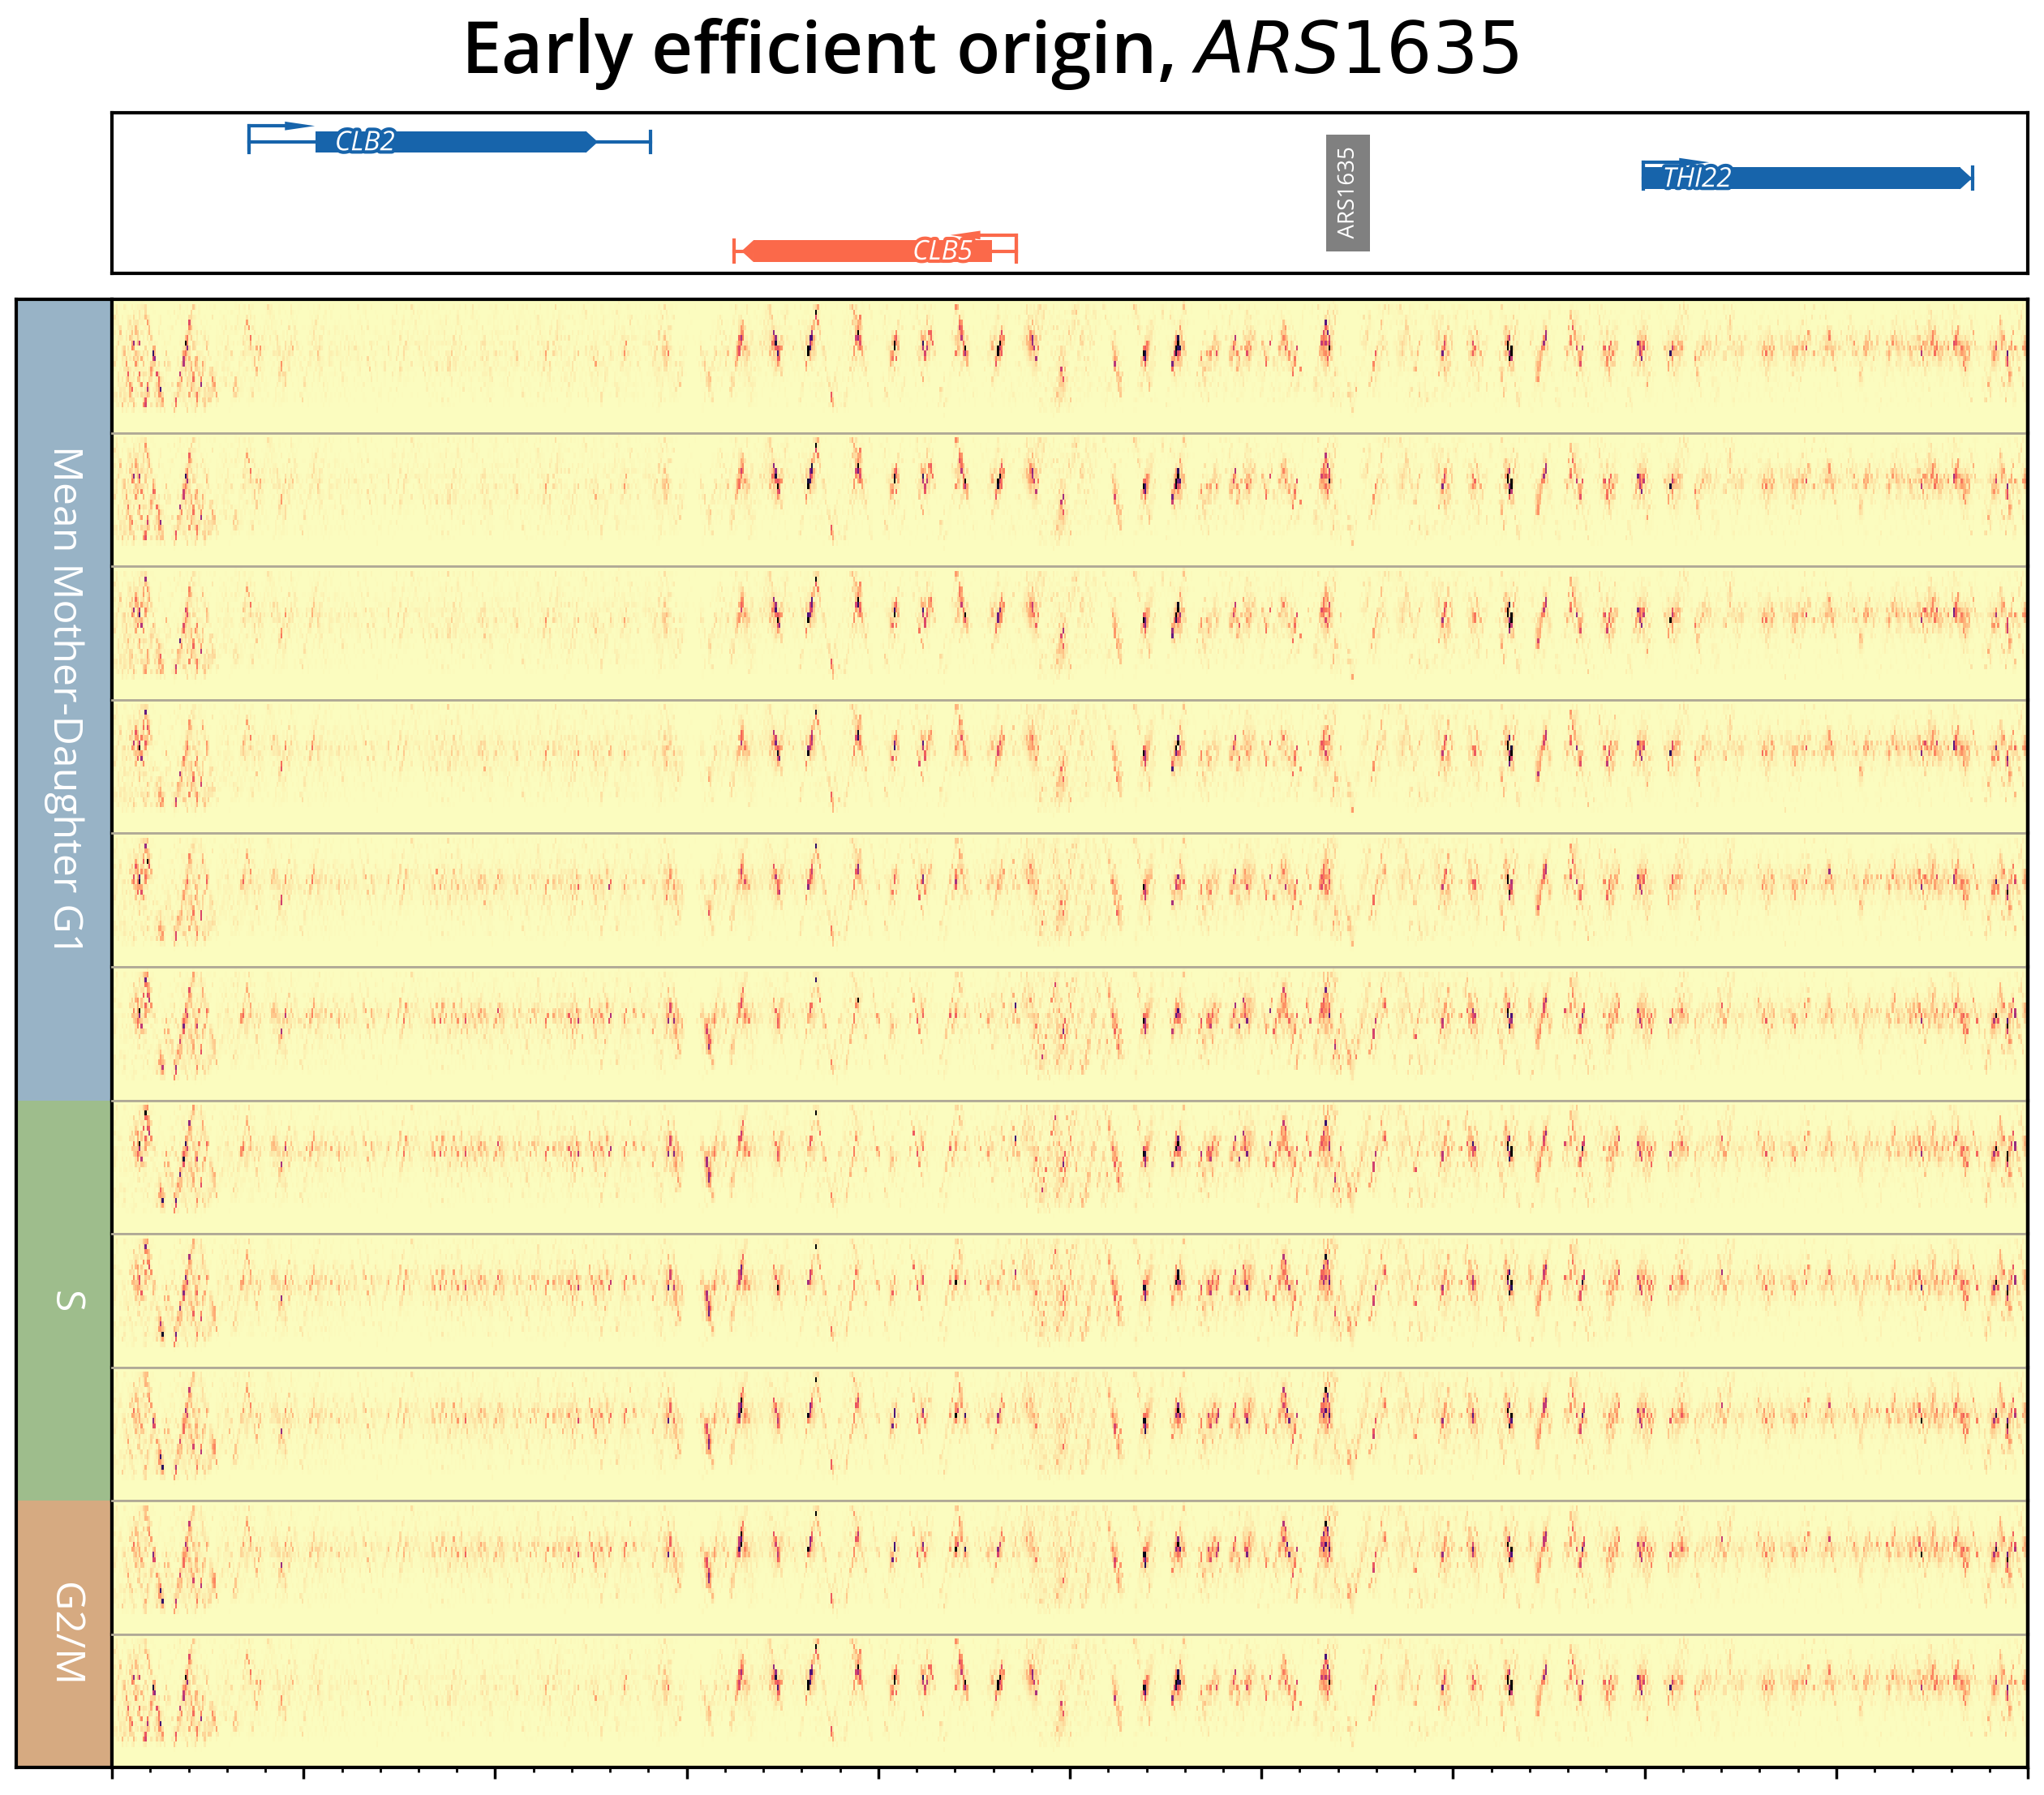

In [188]:
from src.config import load_default_chrom_configs
from src.figure_configs import save_figure_for_paper

ars_name_mapping = {
    'ARS1626.5': 'ARS1635' # Alias term in Belksy set compared to SGD R64
}

if origin.ars_name in ars_name_mapping.keys():
    ars_name = ars_name_mapping[origin.ars_name]
else:
    ars_name = origin.ars_name.ars_name

config1, config2 = load_default_chrom_configs()
genome_analysis.plot_loaded_data(config1, figsize=(16, 12), 
    title="Early efficient origin, $\\it{" + ars_name + "}$")

save_figure_for_paper("/Users/trung/Desktop/example_locus.png")

In [263]:
from src.replication_timing import ReplicationTiming

replication_timings = ReplicationTiming('output/draft3_run/')

In [269]:
chr_origins = origins[origins.chr == origin.chr]

(0.0, 1.0)

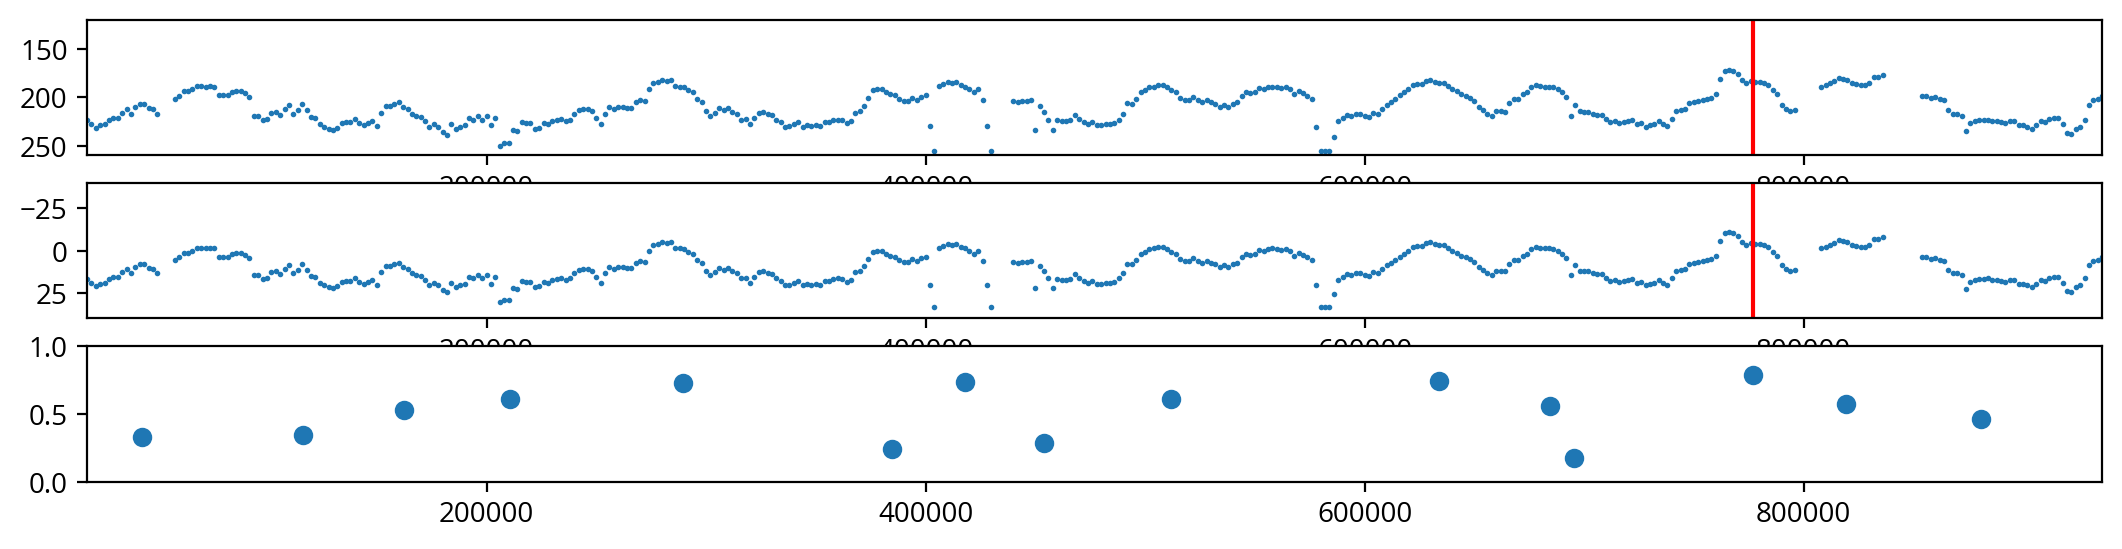

In [275]:
plt.figure(figsize=(13, 3))

chr_replication = replication_timings.replications_df.loc[origin.chr]

plt.subplot(3, 1, 1)
plt.scatter(chr_replication.index,
    chr_replication['replication_index_b'], s=1)
plt.xlim(chr_replication.index[0], chr_replication.index[-1])
plt.ylim(260, 120)
plt.axvline(origin.pos, c='red')

plt.subplot(3, 1, 2)
plt.scatter(chr_replication.index,
    chr_replication['replication_time'], s=1)
plt.xlim(chr_replication.index[0], chr_replication.index[-1])
plt.ylim(40, -40)
plt.axvline(origin.pos, c='red')

plt.subplot(3, 1, 3)
plt.scatter(chr_origins.pos, chr_origins.derived_origin_efficiency_from_mcguffee_et_al_2013)
plt.xlim(chr_replication.index[0], chr_replication.index[-1])
plt.ylim(0, 1)

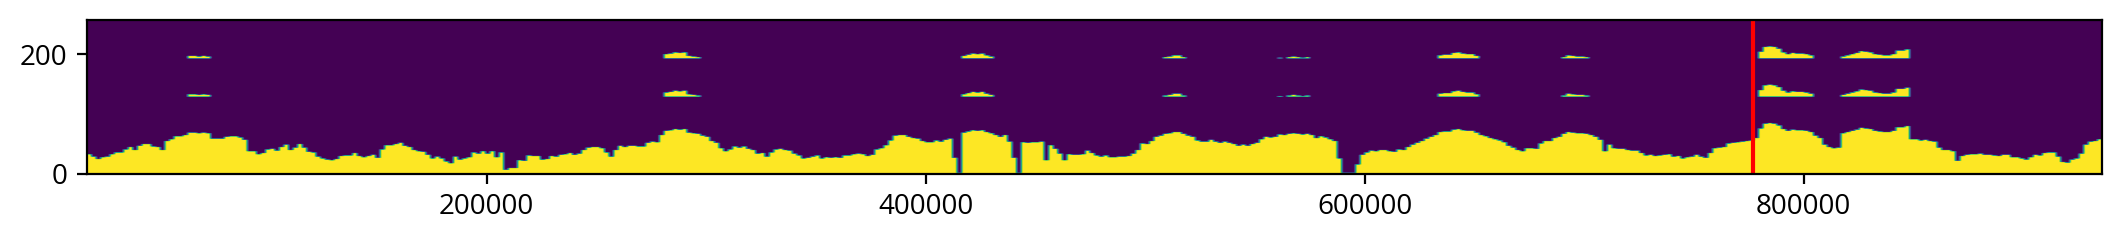

In [267]:
chr16_repl_F = pd.read_csv('output/draft3_run/combined_replication/combined_chr16_F.csv')
chr16_repl_F = chr16_repl_F[chr16_repl_F.columns[1:]]
chr16_repl_F.columns = chr16_repl_F.columns.astype(int)

plt.figure(figsize=(13, 1))
plt.imshow(chr16_repl_F, aspect='auto',
          extent=[chr_replication.index[0], chr_replication.index[-1],
                 0, len(chr16_repl_F)])
plt.axvline(origin.pos, c='red')